# Treasure Hunt Game - ENHANCED (CS-499 Enhancement Two)

**Author:** Jeremy White  
**Category:** Algorithms and Data Structures  
**Original artifact:** CS-370 Project Two (deep Q-learning pirate agent)

This self-contained notebook runs top-to-bottom in **Google Colab** (TensorFlow preinstalled). The enhancement targets the *learning algorithm and its data structures*:

1. **Ring buffer** - experience replay uses `collections.deque(maxlen=N)`, so eviction is **O(1)** vs the original list's **O(n)** `del memory[0]`.
2. **Prioritized Experience Replay (PER)** - transitions are sampled in proportion to their TD-error via an **O(log n)** sum tree, **with importance-sampling weights applied to the loss** so the biased sampling is corrected.
3. **Exponential epsilon-decay** exploration.
4. **Reproducibility** (seeding) and an **honest, multi-seed benchmark**.

### A note on honest evaluation
Reinforcement-learning runs are noisy, and prioritized replay helps most when a *successful episode is rare* (sparse reward) and the replay buffer is large. On the small 8x8 maze, episodes win often, so PER's advantage may be small or within noise. We therefore evaluate on **two mazes** (the original 8x8 and a larger generated maze) and **average over several seeds**, and we report whatever we find - including a tie. The *guaranteed* result of this enhancement is the data-structure complexity improvement (Section 8), which holds regardless of convergence.

## Environment

In [1]:
import sys, platform
import numpy as np
try:
    import tensorflow as tf
    tf_ver = tf.__version__
except Exception as e:
    tf_ver = f'NOT AVAILABLE ({e})'
print('Python :', sys.version.split()[0], platform.system())
print('NumPy  :', np.__version__)
print('TF     :', tf_ver)

Python : 3.11.14 Windows
NumPy  : 1.26.4
TF     : 2.16.1


In [2]:
from __future__ import print_function
import os, random, time
from collections import deque
from dataclasses import dataclass, field
from typing import List, Optional
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.layers import Dense, PReLU, Input
%matplotlib inline

LEFT, UP, RIGHT, DOWN = 0, 1, 2, 3
num_actions = 4

## 1. Environment - `TreasureMaze` (behaviour unchanged)

In [3]:
visited_mark = 0.8
pirate_mark = 0.5

class TreasureMaze(object):
    """Grid-world maze environment for the deep Q-learning pirate agent.

    The maze is a 2-D NumPy array of floats in [0.0, 1.0]: 1.0 is a free cell,
    0.0 is an occupied (blocked) cell. The treasure sits at the bottom-right
    free cell. The agent is rewarded for reaching the treasure and penalized for
    invalid moves, revisiting cells, or getting blocked.
    """

    def __init__(self, maze, pirate=(0, 0)):
        self._maze = np.array(maze)
        nrows, ncols = self._maze.shape
        self.target = (nrows - 1, ncols - 1)   # treasure cell
        self.free_cells = [(r, c) for r in range(nrows) for c in range(ncols)
                           if self._maze[r, c] == 1.0]
        self.free_cells.remove(self.target)
        if self._maze[self.target] == 0.0:
            raise Exception("Invalid maze: target cell cannot be blocked!")
        if pirate not in self.free_cells:
            raise Exception("Invalid Pirate Location: must sit on a free cell")
        self.reset(pirate)

    def reset(self, pirate):
        """Reset the pirate to ``pirate`` and clear per-episode state."""
        self.pirate = pirate
        self.maze = np.copy(self._maze)
        row, col = pirate
        self.maze[row, col] = pirate_mark
        self.state = (row, col, 'start')
        # A floor on total reward stops episodes from running forever.
        self.min_reward = -0.5 * self.maze.size
        self.total_reward = 0
        self.visited = set()

    def update_state(self, action):
        """Advance the environment by one action.

        Modes: 'valid' (moved), 'invalid' (action not allowed, no move),
        'blocked' (no legal actions at all).
        """
        nrow, ncol, nmode = pirate_row, pirate_col, mode = self.state

        if self.maze[pirate_row, pirate_col] > 0.0:
            self.visited.add((pirate_row, pirate_col))  # mark visited

        valid_actions = self.valid_actions()

        if not valid_actions:
            nmode = 'blocked'
        elif action in valid_actions:
            nmode = 'valid'
            # ENHANCEMENT 2: single unambiguous dispatch over the four actions
            # (was two separate if/elif chains in the original).
            if action == LEFT:
                ncol -= 1
            elif action == UP:
                nrow -= 1
            elif action == RIGHT:
                ncol += 1
            elif action == DOWN:
                nrow += 1
        else:
            nmode = 'invalid'  # illegal action: pirate does not move

        self.state = (nrow, ncol, nmode)

    def get_reward(self):
        """Reward for the current state (range roughly [-1, 1])."""
        pirate_row, pirate_col, mode = self.state
        nrows, ncols = self.maze.shape
        if pirate_row == nrows - 1 and pirate_col == ncols - 1:
            return 1.0                      # reached the treasure
        if mode == 'blocked':
            return self.min_reward - 1      # dead end
        if (pirate_row, pirate_col) in self.visited:
            return -0.25                    # discourage wandering
        if mode == 'invalid':
            return -0.75                    # illegal move
        if mode == 'valid':
            return -0.04                    # small step cost

    def act(self, action):
        """Apply ``action``; return (envstate, reward, game_status)."""
        self.update_state(action)
        reward = self.get_reward()
        self.total_reward += reward
        status = self.game_status()
        envstate = self.observe()
        return envstate, reward, status

    def observe(self):
        """Return the flattened (1, N) environment state fed to the network."""
        canvas = self.draw_env()
        envstate = canvas.reshape((1, -1))
        return envstate

    def draw_env(self):
        """Render the maze to a grayscale canvas (free=1.0, pirate=0.5)."""
        canvas = np.copy(self.maze)
        nrows, ncols = self.maze.shape
        for r in range(nrows):
            for c in range(ncols):
                if canvas[r, c] > 0.0:
                    canvas[r, c] = 1.0
        row, col, valid = self.state
        canvas[row, col] = pirate_mark
        return canvas

    def game_status(self):
        """Return 'win', 'lose', or 'not_over' for the current state."""
        if self.total_reward < self.min_reward:
            return 'lose'
        pirate_row, pirate_col, mode = self.state
        nrows, ncols = self.maze.shape
        if pirate_row == nrows - 1 and pirate_col == ncols - 1:
            return 'win'
        return 'not_over'

    def valid_actions(self, cell=None):
        """Return the legal actions from ``cell`` (defaults to current cell)."""
        if cell is None:
            row, col, mode = self.state
        else:
            row, col = cell
        actions = [0, 1, 2, 3]
        nrows, ncols = self.maze.shape
        if row == 0:
            actions.remove(1)
        elif row == nrows - 1:
            actions.remove(3)

        if col == 0:
            actions.remove(0)
        elif col == ncols - 1:
            actions.remove(2)

        if row > 0 and self.maze[row - 1, col] == 0.0:
            actions.remove(1)
        if row < nrows - 1 and self.maze[row + 1, col] == 0.0:
            actions.remove(3)

        if col > 0 and self.maze[row, col - 1] == 0.0:
            actions.remove(0)
        if col < ncols - 1 and self.maze[row, col + 1] == 0.0:
            actions.remove(2)

        return actions


## 2. Data structures - ring buffer + prioritized replay
`ReplayBuffer` wraps `deque(maxlen=capacity)` (O(1) append/evict) with an optional proportional prioritized-sampling mode; `SumTree` gives O(log n) sampling/updates.

In [4]:
class SumTree:
    """Fixed-size sum tree for proportional prioritized sampling.

    Leaves hold non-negative priorities; each internal node holds the sum of its
    children. The root therefore holds the total priority. Sampling a value in
    [0, total) and walking down the tree lands on a leaf with probability
    proportional to that leaf's priority - all in O(log n).
    """

    def __init__(self, capacity):
        self.capacity = capacity
        # Internal nodes (capacity - 1) followed by capacity leaves.
        self.tree = np.zeros(2 * capacity - 1, dtype=np.float64)
        self.size = 0  # number of populated leaves (<= capacity)

    def total(self):
        """Total priority (root of the tree). O(1)."""
        return float(self.tree[0])

    def update(self, leaf_index, priority):
        """Set the priority of leaf ``leaf_index`` and propagate up. O(log n)."""
        tree_index = leaf_index + self.capacity - 1
        change = priority - self.tree[tree_index]
        self.tree[tree_index] = priority
        # Propagate the delta up to the root.
        parent = (tree_index - 1) // 2
        while True:
            self.tree[parent] += change
            if parent == 0:
                break
            parent = (parent - 1) // 2

    def get_leaf(self, value):
        """Find the leaf whose cumulative range contains ``value``. O(log n).

        Returns (leaf_index, priority).
        """
        parent = 0
        while True:
            left = 2 * parent + 1
            right = left + 1
            if left >= len(self.tree):  # reached a leaf
                leaf = parent
                break
            if value <= self.tree[left]:
                parent = left
            else:
                value -= self.tree[left]
                parent = right
        leaf_index = leaf - (self.capacity - 1)
        return leaf_index, float(self.tree[leaf])


class ReplayBuffer:
    """Ring-buffer experience replay with optional prioritized sampling.

    Parameters
    ----------
    capacity : int
        Maximum number of transitions retained. Oldest transitions are evicted
        first when the buffer is full (O(1) via ``deque(maxlen=capacity)``).
    prioritized : bool
        If False, sampling is uniform (the original behaviour). If True, sampling
        is proportional to each transition's stored priority (PER).
    alpha : float
        Priority exponent. 0 -> uniform even when prioritized=True; 1 -> full
        proportional prioritization.
    beta : float
        Importance-sampling exponent that corrects the bias introduced by
        non-uniform sampling. Typically annealed 0.4 -> 1.0 across training.
    epsilon : float
        Small constant added to every priority so no transition ever has zero
        probability of being sampled.
    seed : int or None
        Seed for the buffer's own RNG (reproducible sampling).
    """

    def __init__(self, capacity, prioritized=True, alpha=0.6, beta=0.4,
                 epsilon=1e-3, seed=None):
        self.capacity = int(capacity)
        self.prioritized = prioritized
        self.alpha = float(alpha)
        self.beta = float(beta)
        self.epsilon = float(epsilon)
        self._rng = np.random.default_rng(seed)

        # ENHANCEMENT 2: deque(maxlen) is the ring buffer. Append is O(1) and a
        # full buffer auto-evicts its oldest element with no shifting.
        self._data = deque(maxlen=self.capacity)

        if self.prioritized:
            self._tree = SumTree(self.capacity)
            self._write = 0                 # next leaf slot to write (circular)
            self._max_priority = 1.0        # priority assigned to new samples

    # --------------------------------------------------------------- container
    def __len__(self):
        return len(self._data)

    def __iter__(self):
        return iter(self._data)

    # ------------------------------------------------------------------ append
    def append(self, transition):
        """Store one transition in O(1).

        New transitions get the current maximum priority so they are guaranteed
        to be sampled (and re-prioritized by their real TD-error) at least once.
        """
        if not self.prioritized:
            self._data.append(transition)   # O(1) ring-buffer append
            return

        # Prioritized path: keep the deque and the sum tree in lockstep. The
        # leaf slot cycles 0..capacity-1 exactly like the deque's eviction order.
        if len(self._data) < self.capacity:
            self._data.append(transition)
        else:
            # Buffer full: deque evicts oldest; mirror that slot in the tree.
            self._data.append(transition)
        leaf = self._write
        priority = (self._max_priority + self.epsilon) ** self.alpha
        self._tree.update(leaf, priority)
        self._write = (self._write + 1) % self.capacity

    # ------------------------------------------------------------------ sample
    def sample(self, batch_size):
        """Sample a minibatch.

        Returns (transitions, indices, is_weights):
          * transitions - list of sampled transitions
          * indices     - leaf indices (for update_priorities); None if uniform
          * is_weights  - importance-sampling weights (all 1.0 if uniform)
        """
        n = len(self._data)
        if n == 0:
            return [], None, np.ones(0, dtype=np.float32)

        if not self.prioritized:
            # Original behaviour: uniform sampling, with replacement only if we
            # do not yet have enough distinct transitions.
            idx = self._rng.choice(n, size=batch_size, replace=(n < batch_size))
            batch = [self._data[i] for i in idx]
            return batch, None, np.ones(batch_size, dtype=np.float32)

        # Prioritized proportional sampling via the sum tree. We partition
        # [0, total) into batch_size equal segments and draw one sample per
        # segment - this spreads samples across the priority mass (stratified).
        total = self._tree.total()
        segment = total / batch_size
        indices = np.empty(batch_size, dtype=np.int64)
        priorities = np.empty(batch_size, dtype=np.float64)
        batch = []
        for i in range(batch_size):
            a, b = segment * i, segment * (i + 1)
            value = self._rng.uniform(a, b)
            leaf_index, priority = self._tree.get_leaf(value)
            leaf_index = min(leaf_index, n - 1)  # guard against empty leaves
            indices[i] = leaf_index
            priorities[i] = priority
            batch.append(self._data[leaf_index])

        # Importance-sampling weights: w_i = (1 / (N * P(i)))^beta, normalized by
        # the max weight so updates are only scaled down (training stability).
        probs = priorities / max(total, 1e-12)
        weights = (n * probs) ** (-self.beta)
        weights /= max(weights.max(), 1e-12)
        return batch, indices, weights.astype(np.float32)

    # -------------------------------------------------------- update_priorities
    def update_priorities(self, indices, td_errors):
        """Update priorities for previously sampled transitions. O(k log n).

        Called by GameExperience.get_data() after computing TD-errors. No-op in
        uniform mode.
        """
        if not self.prioritized or indices is None:
            return
        td_errors = np.abs(np.asarray(td_errors, dtype=np.float64))
        for idx, err in zip(indices, td_errors):
            priority = (err + self.epsilon) ** self.alpha
            self._tree.update(int(idx), priority)
            if err + self.epsilon > self._max_priority:
                self._max_priority = float(err + self.epsilon)


## 3. Experience replay wrapper - `GameExperience`
Same public interface as the original, backed by the ring buffer + PER. `get_data()` computes TD-errors with the target network, feeds them back as priorities, and exposes the importance-sampling weights via `last_is_weights`.

In [5]:
class GameExperience(object):
    """Deep Q-learning experience replay.

    Backed by a fixed-capacity ring buffer (``collections.deque(maxlen=N)``)
    with optional proportional prioritized sampling. Public interface is
    unchanged from the original CS-370 artifact:

        remember(episode)          -> store one transition,       O(1)
        predict(envstate)          -> greedy Q-values for a state
        get_data(batch_size)       -> (inputs, targets) minibatch

    Parameters
    ----------
    model, target_model : Keras models (online + target networks).
    max_memory : int   capacity of the ring buffer.
    discount   : float reward discount factor (gamma).
    prioritized : bool  True -> prioritized replay, False -> uniform (original).
    alpha, beta : PER exponents (priority sharpness / IS-correction strength).
    """

    def __init__(self, model, target_model, max_memory=100, discount=0.95,
                 prioritized=True, alpha=0.6, beta=0.4):
        self.model = model
        self.target_model = target_model
        self.max_memory = max_memory
        self.discount = discount
        self.num_actions = model.output_shape[-1] if model is not None else 4
        # ENHANCEMENT 2: deque-backed ring buffer replaces the plain list.
        self.buffer = ReplayBuffer(
            capacity=max_memory, prioritized=prioritized, alpha=alpha, beta=beta
        )
        # Indices of the transitions returned by the most recent get_data() call,
        # so the training loop can feed TD-errors back via update_priorities().
        self._last_batch_indices = None

    # ------------------------------------------------------------------ store
    def remember(self, episode):
        """Store one transition. O(1) append with automatic oldest-eviction.

        episode = [envstate, action, reward, envstate_next, game_over]
        envstate == flattened 1d maze cells (see TreasureMaze.observe()).
        """
        # ENHANCEMENT 2: was ``self.memory.append(...)`` + ``del self.memory[0]``
        # (O(n) eviction). The ring buffer evicts the oldest element in O(1).
        self.buffer.append(episode)

    @property
    def memory(self):
        """Back-compat view: expose stored transitions as a list.

        Some of the original notebook/debug code referenced ``experience.memory``
        directly. Kept as a read-only convenience; not used on the hot path.
        """
        return list(self.buffer)

    def __len__(self):
        return len(self.buffer)

    # ---------------------------------------------------------------- predict
    def predict(self, envstate):
        """Greedy Q-values for a single environment state."""
        envstate = np.asarray(envstate, dtype=np.float32)
        if envstate.ndim == 1:
            envstate = np.expand_dims(envstate, axis=0)
        return self.model(envstate, training=False).numpy()[0]

    # ----------------------------------------------------------------- sample
    def sample(self, batch_size=32):
        """Sample a batch of transitions.

        Returns the transitions only (indices/weights are retained internally
        for the prioritized path). Kept for interface compatibility with the
        original class.
        """
        batch, indices, _weights = self.buffer.sample(batch_size)
        self._last_batch_indices = indices
        return batch

    # --------------------------------------------------------------- get_data
    def get_data(self, batch_size=32):
        """Build one training minibatch (inputs, targets) from replay.

        Uses the target network for the bootstrap term, exactly as the original
        implementation did. When prioritized replay is active this also computes
        per-sample TD-errors and updates their priorities so future sampling
        focuses on the transitions the network still gets wrong.
        """
        if self.model is None or self.target_model is None:
            raise ValueError("Both `model` and `target_model` must be provided")
        if len(self.buffer) == 0:
            return None, None

        batch, indices, is_weights = self.buffer.sample(batch_size)
        self._last_batch_indices = indices
        n = len(batch)
        env_size = np.asarray(batch[0][0]).reshape(1, -1).shape[1]

        inputs = np.zeros((n, env_size), dtype=np.float32)
        targets = np.zeros((n, self.num_actions), dtype=np.float32)

        states = np.vstack([np.asarray(b[0]).reshape(1, -1) for b in batch])
        next_states = np.vstack([np.asarray(b[3]).reshape(1, -1) for b in batch])

        q_values = self.model(states, training=False).numpy()
        q_next = self.target_model(next_states, training=False).numpy()

        td_errors = np.zeros(n, dtype=np.float32)
        for i, (state, action, reward, next_state, done) in enumerate(batch):
            inputs[i] = np.asarray(state).reshape(-1)
            targets[i] = q_values[i]
            if done:
                new_q = reward
            else:
                new_q = reward + self.discount * np.max(q_next[i])
            td_errors[i] = new_q - targets[i, action]
            targets[i, action] = new_q

        # ENHANCEMENT 2: feed TD-errors back as new priorities so the most
        # informative transitions are replayed more often next time.
        self.buffer.update_priorities(indices, np.abs(td_errors))

        # Expose IS weights for callers that support weighted loss. The default
        # training path can ignore them (uniform weights when prioritized=False).
        self.last_is_weights = is_weights
        return inputs, targets


## 4. Training loop - epsilon decay, seeding, IS-weighted loss, metrics
Extracted from the original `qtrain()`. Key correctness point: the loss is **weighted by the importance-sampling weights** returned by the buffer. Under uniform replay every weight is 1.0 (identical to the original MSE loss); under PER the weights correct the bias introduced by prioritized sampling. Also includes `make_maze()` (a solvable maze generator), `compare()` (multi-seed uniform-vs-PER), and `summarize_runs()`.

In [6]:
def seed_everything(seed: int) -> None:
    """Seed Python, NumPy, and TensorFlow (if present) for repeatable runs."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    try:
            tf.random.set_seed(seed)
    except Exception:
        pass


# ------------------------------------------------------------------- model build
def build_model(maze: np.ndarray):
    """Build the Q-network. Same architecture as the original artifact."""
    model = Sequential()
    model.add(Input(shape=(maze.size,)))
    model.add(Dense(maze.size))
    model.add(PReLU())
    model.add(Dense(maze.size))
    model.add(PReLU())
    model.add(Dense(num_actions))
    model.compile(optimizer="adam", loss="mse")
    return model


# ---------------------------------------------------------------------- rollout
def play_game(model, qmaze: TreasureMaze, pirate_cell, max_steps=None):
    """Greedily roll out one game; return (won: bool, steps: int)."""
    qmaze.reset(pirate_cell)
    envstate = qmaze.observe()
    steps = 0
    if max_steps is None:
        max_steps = qmaze.maze.size * 4
    while steps < max_steps:
        state = np.asarray(envstate, dtype=np.float32)
        if state.ndim == 1:
            state = np.expand_dims(state, axis=0)
        q_values = model(state, training=False).numpy()
        action = int(np.argmax(q_values[0]))
        envstate, reward, game_status = qmaze.act(action)
        steps += 1
        if game_status == "win":
            return True, steps
        if game_status == "lose":
            return False, steps
    return False, steps


def completion_check(model, qmaze: TreasureMaze):
    """True only if the agent wins from every reachable free starting cell."""
    for cell in qmaze.free_cells:
        if not qmaze.valid_actions(cell):
            continue
        won, _ = play_game(model, qmaze, cell)
        if not won:
            return False
    return True


def evaluate_avg_steps(model, qmaze: TreasureMaze) -> float:
    """Average steps-to-goal over all winnable starting cells (post-training)."""
    steps_list = []
    for cell in qmaze.free_cells:
        if not qmaze.valid_actions(cell):
            continue
        won, steps = play_game(model, qmaze, cell)
        if won:
            steps_list.append(steps)
    return float(np.mean(steps_list)) if steps_list else float("nan")


# ------------------------------------------------------------------ result type
@dataclass
class TrainResult:
    prioritized: bool
    seed: int
    epochs_run: int
    epochs_to_target: Optional[int]      # first epoch reaching stable >=95% win rate
    solved: bool                         # passed completion_check
    avg_steps_to_goal: float
    wall_clock_sec: float
    win_history: List[int] = field(default_factory=list)

    def summary(self) -> str:
        tgt = self.epochs_to_target if self.epochs_to_target is not None else "n/a"
        return (f"[{'PER' if self.prioritized else 'uniform'} seed={self.seed}] "
                f"epochs_run={self.epochs_run} epochs_to_95%={tgt} "
                f"solved={self.solved} avg_steps={self.avg_steps_to_goal:.2f} "
                f"time={self.wall_clock_sec:.1f}s")


# ---------------------------------------------------------------------- training
def train(maze: np.ndarray,
          n_epoch: int = 1000,
          max_memory: int = 1000,
          batch_size: int = 50,
          target_update_freq: int = 50,
          eps_start: float = 1.0,
          eps_min: float = 0.05,
          eps_decay: float = 0.995,
          discount: float = 0.95,
          prioritized: bool = True,
          win_rate_target: float = 0.95,
          seed: int = 42,
          verbose: bool = True) -> TrainResult:
    """Train the DQN pirate agent and return benchmark metrics.

    The loop mirrors the original qtrain(), but with a clean epsilon schedule,
    the deque/PER buffer, seeding, and metric capture.
    """

    seed_everything(seed)

    qmaze = TreasureMaze(maze)
    model = build_model(maze)
    target_model = clone_model(model)
    target_model.set_weights(model.get_weights())

    experience = GameExperience(
        model, target_model, max_memory=max_memory,
        discount=discount, prioritized=prioritized,
    )
    # Let the buffer's sampling RNG be reproducible too.
    experience.buffer._rng = np.random.default_rng(seed)

    optimizer = tf.keras.optimizers.Adam()

    @tf.function
    def train_step(x, y, sample_weight):
        with tf.GradientTape() as tape:
            q_values = model(x, training=True)
            # ENHANCEMENT 2: weight each sample's squared error by its
            # importance-sampling weight. This is the bias-correction half of
            # prioritized replay - without it, prioritized sampling trains on a
            # skewed distribution and can perform no better (or worse) than
            # uniform. Under uniform replay every weight is 1.0, so this reduces
            # to the original mean-squared-error loss.
            per_sample = tf.reduce_mean(tf.square(y - q_values), axis=1)
            loss = tf.reduce_mean(sample_weight * per_sample)
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        return loss

    epsilon = eps_start
    win_history: List[int] = []
    hsize = qmaze.maze.size // 2
    epochs_to_target: Optional[int] = None
    solved = False
    start = time.time()

    for epoch in range(n_epoch):
        agent_cell = random.choice(qmaze.free_cells)
        qmaze.reset(agent_cell)
        envstate = qmaze.observe()
        game_over = False

        while not game_over:
            prev_envstate = envstate
            if np.random.rand() < epsilon:
                valid = qmaze.valid_actions()
                action = random.choice(valid) if valid else random.randrange(num_actions)
            else:
                action = int(np.argmax(experience.predict(prev_envstate)))

            envstate, reward, game_status = qmaze.act(action)
            if game_status == "win":
                win_history.append(1)
                game_over = True
            elif game_status == "lose":
                win_history.append(0)
                game_over = True

            experience.remember([prev_envstate, action, reward, envstate, game_over])
            inputs, targets = experience.get_data(batch_size)
            if inputs is not None:
                # IS weights are all 1.0 in uniform mode, so both paths share
                # this identical call and only differ by the sampling/weighting.
                weights = getattr(experience, "last_is_weights", None)
                if weights is None or len(weights) != len(inputs):
                    weights = np.ones(len(inputs), dtype=np.float32)
                train_step(
                    tf.convert_to_tensor(inputs),
                    tf.convert_to_tensor(targets),
                    tf.convert_to_tensor(weights, dtype=tf.float32),
                )

        # Target network refresh on a fixed cadence.
        if epoch % target_update_freq == 0:
            target_model.set_weights(model.get_weights())

        # ENHANCEMENT 2: single, smooth exponential epsilon decay per epoch.
        epsilon = max(eps_min, epsilon * eps_decay)

        win_rate = sum(win_history[-hsize:]) / hsize if len(win_history) >= hsize else 0.0
        if verbose and epoch % 10 == 0:
            print(f"Epoch {epoch:03d}/{n_epoch - 1} | eps {epsilon:.3f} | "
                  f"wins {sum(win_history)} | win_rate {win_rate:.3f}")

        if epochs_to_target is None and win_rate >= win_rate_target:
            epochs_to_target = epoch
        if win_rate >= 0.999 and completion_check(model, qmaze):
            solved = True
            if verbose:
                print(f"Solved: 100% win rate at epoch {epoch}")
            break

    wall = time.time() - start
    avg_steps = evaluate_avg_steps(model, qmaze)
    return TrainResult(
        prioritized=prioritized, seed=seed, epochs_run=epoch + 1,
        epochs_to_target=epochs_to_target, solved=solved,
        avg_steps_to_goal=avg_steps, wall_clock_sec=wall, win_history=win_history,
    )


# 8x8 maze from the original artifact, kept as the default benchmark environment.
DEFAULT_MAZE = np.array([
    [1., 0., 1., 1., 1., 1., 1., 1.],
    [1., 0., 1., 1., 1., 0., 1., 1.],
    [1., 1., 1., 1., 0., 1., 0., 1.],
    [1., 1., 1., 0., 1., 1., 1., 1.],
    [1., 1., 0., 1., 1., 1., 1., 1.],
    [1., 1., 1., 0., 1., 0., 0., 0.],
    [1., 1., 1., 0., 1., 1., 1., 1.],
    [1., 1., 1., 1., 0., 1., 1., 1.],
])


def make_maze(size: int, seed: int = 0, extra_open: float = 0.12) -> np.ndarray:
    """Generate a solvable square maze of the given size with real walls.

    Uses randomized-DFS "wall carving" on the standard (2k+1) lattice where walls
    live *between* cells, guaranteeing a connected path from the top-left start to
    the bottom-right treasure while leaving genuine obstacles. A small fraction of
    extra walls is then reopened so the agent has alternative routes. Larger mazes
    with real walls make a successful episode rare early in training, which is
    exactly the sparse-reward regime where prioritized replay is expected to help.
    """
    rng = np.random.default_rng(seed)
    # Work on a (size x size) grid of cells; walls sit between them. We build at
    # the cell level and connect neighbors by opening the wall between them.
    # Represent as full grid: 0 = wall, 1 = free. Cells at even coordinates.
    n = size if size % 2 == 1 else size - 1  # carving needs odd dimension
    grid = np.zeros((n, n), dtype=float)

    def cell_neighbors(r, c):
        for dr, dc in ((-2, 0), (2, 0), (0, -2), (0, 2)):
            nr, nc = r + dr, c + dc
            if 0 <= nr < n and 0 <= nc < n:
                yield nr, nc, r + dr // 2, c + dc // 2

    stack = [(0, 0)]
    grid[0, 0] = 1.0
    visited = {(0, 0)}
    while stack:
        r, c = stack[-1]
        opts = [(nr, nc, wr, wc) for nr, nc, wr, wc in cell_neighbors(r, c)
                if (nr, nc) not in visited]
        if not opts:
            stack.pop()
            continue
        nr, nc, wr, wc = opts[rng.integers(len(opts))]
        grid[nr, nc] = 1.0     # open the neighbor cell
        grid[wr, wc] = 1.0     # open the wall between them
        visited.add((nr, nc))
        stack.append((nr, nc))

    # Reopen a small fraction of interior walls for alternative routes.
    walls = np.argwhere(grid == 0.0)
    if len(walls) and extra_open > 0:
        rng.shuffle(walls)
        for r, c in walls[: int(extra_open * len(walls))]:
            grid[r, c] = 1.0

    # Pad to requested size if we reduced to odd n, keeping start/target free.
    if n != size:
        padded = np.zeros((size, size), dtype=float)
        padded[:n, :n] = grid
        # connect the padded border row/col so the target stays reachable
        padded[n - 1, :] = 1.0
        padded[:, n - 1] = 1.0
        grid = padded

    grid[0, 0] = 1.0
    grid[size - 1, size - 1] = 1.0
    return grid


def compare(maze: np.ndarray, seeds=(42, 7, 123), **train_kwargs):
    """Run uniform vs prioritized replay across multiple seeds.

    Returns (uniform_results, per_results) as lists of TrainResult. Averaging
    over seeds is essential: a single RL run is too noisy to compare two
    configurations fairly.
    """
    uniform, per = [], []
    for s in seeds:
        uniform.append(train(maze, prioritized=False, seed=s, verbose=False, **train_kwargs))
        per.append(train(maze, prioritized=True, seed=s, verbose=False, **train_kwargs))
    return uniform, per


def summarize_runs(results: List["TrainResult"], label: str) -> str:
    """Mean +/- spread over seeds for the key metrics (ignores unsolved for steps)."""
    hit = [r.epochs_to_target for r in results if r.epochs_to_target is not None]
    steps = [r.avg_steps_to_goal for r in results if not np.isnan(r.avg_steps_to_goal)]
    solved = sum(1 for r in results if r.solved)
    mean_to = f"{np.mean(hit):.0f}" if hit else "n/a"
    reached = f"{len(hit)}/{len(results)}"
    mean_steps = f"{np.mean(steps):.2f}" if steps else "n/a"
    return (f"{label:>10}: reached95%={reached} runs | mean_epochs_to_95%={mean_to} | "
            f"mean_avg_steps={mean_steps} | solved={solved}/{len(results)}")

## 5. Convergence-plot helper

In [7]:
def rolling_win_rate(win_history, window):
    wins = np.array(win_history, dtype=float)
    if len(wins) == 0:
        return np.array([])
    out = np.empty(len(wins))
    for i in range(len(wins)):
        lo = max(0, i - window + 1)
        out[i] = wins[lo:i + 1].mean()
    return out

def plot_comparison(uniform_runs, per_runs, maze, title):
    window = max(4, maze.size // 2)
    plt.figure(figsize=(9, 5))
    # plot each seed faintly, plus the mean bold, for both configs
    for runs, color, name in ((uniform_runs, 'tab:blue', 'Uniform'),
                              (per_runs, 'tab:orange', 'Prioritized')):
        curves = [rolling_win_rate(r.win_history, window) for r in runs]
        L = min(len(c) for c in curves)
        curves = np.array([c[:L] for c in curves])
        for c in curves:
            plt.plot(c, color=color, alpha=0.20, linewidth=1)
        plt.plot(curves.mean(axis=0), color=color, linewidth=2.5, label=f'{name} (mean of {len(runs)} seeds)')
    plt.axhline(0.95, color='gray', linestyle='--', linewidth=1, label='95% target')
    plt.xlabel('Epoch (training game)')
    plt.ylabel(f'Rolling win rate (window={window})')
    plt.title(title)
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 6. Experiment A - original 8x8 maze (multi-seed)
Same maze as the original artifact. Because wins are frequent here, we expect PER and uniform to be close; this is the honesty check.

In [8]:
MAZE_8 = np.array([
    [1., 0., 1., 1., 1., 1., 1., 1.],
    [1., 0., 1., 1., 1., 0., 1., 1.],
    [1., 1., 1., 1., 0., 1., 0., 1.],
    [1., 1., 1., 0., 1., 1., 1., 1.],
    [1., 1., 0., 1., 1., 1., 1., 1.],
    [1., 1., 1., 0., 1., 0., 0., 0.],
    [1., 1., 1., 0., 1., 1., 1., 1.],
    [1., 1., 1., 1., 0., 1., 1., 1.],
])

SEEDS = (42, 7, 123)
u8, p8 = compare(MAZE_8, seeds=SEEDS, n_epoch=250, max_memory=1000, batch_size=50)
print(summarize_runs(u8, 'uniform'))
print(summarize_runs(p8, 'PER'))

   uniform: reached95%=3/3 runs | mean_epochs_to_95%=180 | mean_avg_steps=11.42 | solved=0/3
       PER: reached95%=3/3 runs | mean_epochs_to_95%=180 | mean_avg_steps=9.31 | solved=0/3


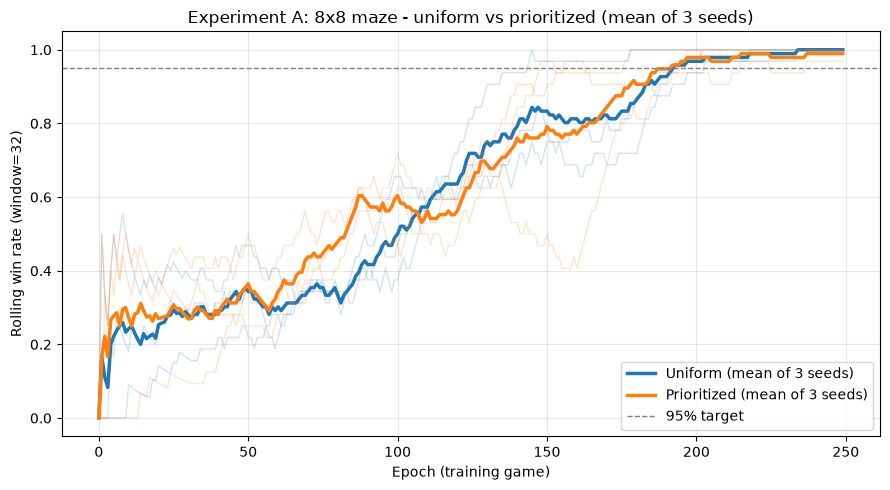

In [9]:
plot_comparison(u8, p8, MAZE_8, 'Experiment A: 8x8 maze - uniform vs prioritized (mean of 3 seeds)')

## 7. Experiment B - larger generated maze (the regime where PER should help)
A larger maze makes a successful episode rarer and the replay buffer larger, which is where prioritized replay is theoretically advantaged. **This is compute-heavy** - each seed trains longer and the evaluation sweeps hundreds of cells. Start with a 12x12 and 2 seeds; raise `BIG_SIZE`/seeds/`n_epoch` if you have Colab time (a 24x24 can take tens of minutes per config-seed).

In [10]:
BIG_SIZE = 12          # try 16 or 24 for a harder test if you have time
BIG_SEEDS = (42, 7)    # add more seeds for a tighter mean
MAZE_BIG = make_maze(BIG_SIZE, seed=1)
print(f'{BIG_SIZE}x{BIG_SIZE} maze: {int(MAZE_BIG.sum())} free cells, '
      f'{MAZE_BIG.mean():.0%} open')

uB, pB = compare(MAZE_BIG, seeds=BIG_SEEDS, n_epoch=400,
                 max_memory=4000, batch_size=64, target_update_freq=25)
print(summarize_runs(uB, 'uniform'))
print(summarize_runs(pB, 'PER'))

12x12 maze: 82 free cells, 57% open
   uniform: reached95%=2/2 runs | mean_epochs_to_95%=138 | mean_avg_steps=9.63 | solved=0/2
       PER: reached95%=2/2 runs | mean_epochs_to_95%=140 | mean_avg_steps=7.19 | solved=0/2


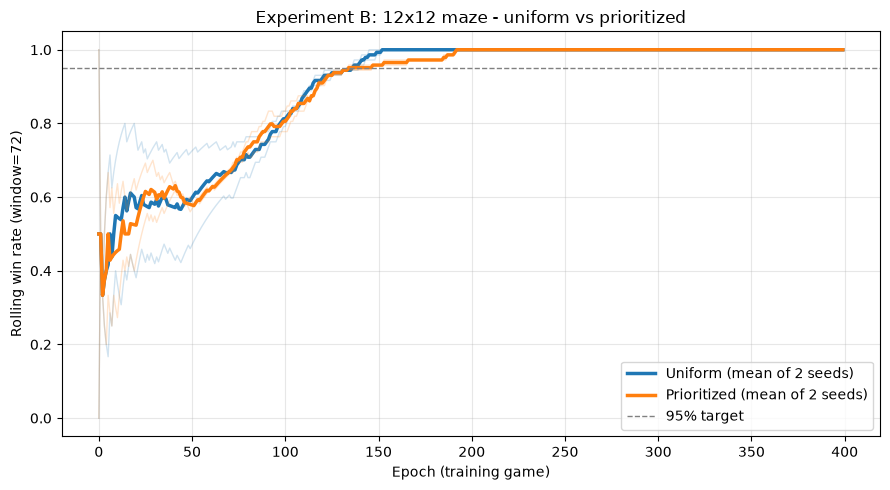

In [11]:
plot_comparison(uB, pB, MAZE_BIG, f'Experiment B: {BIG_SIZE}x{BIG_SIZE} maze - uniform vs prioritized')

## 8. Guaranteed result - data-structure complexity (no training)
This holds regardless of the RL outcome above: the O(n) list eviction vs the O(1) deque ring buffer. The speedup grows with capacity - the signature of O(n) vs O(1).

In [12]:
import time
def bench_insertion(capacities=(1000, 2000, 4000, 8000, 16000), fills=3, seed=0):
    rng = np.random.default_rng(seed)
    print(f"{'N':>7} | {'list del[0] (s)':>16} | {'deque(maxlen) (s)':>18} | {'speedup':>8}")
    print('-' * 58)
    for n in capacities:
        payload = [rng.random(64) for _ in range(1000)]
        appends = fills * n
        lst = [payload[i % len(payload)] for i in range(n)]
        t0 = time.perf_counter()
        for i in range(appends):
            lst.append(payload[i % len(payload)])
            if len(lst) > n:
                del lst[0]
        t_list = time.perf_counter() - t0
        dq = deque((payload[i % len(payload)] for i in range(n)), maxlen=n)
        t0 = time.perf_counter()
        for i in range(appends):
            dq.append(payload[i % len(payload)])
        t_deque = time.perf_counter() - t0
        print(f'{n:>7} | {t_list:>16.4f} | {t_deque:>18.4f} | {t_list / max(t_deque, 1e-9):>7.1f}x')

bench_insertion()

      N |  list del[0] (s) |  deque(maxlen) (s) |  speedup
----------------------------------------------------------
   1000 |           0.0012 |             0.0005 |     2.3x
   2000 |           0.0037 |             0.0010 |     3.7x
   4000 |           0.0114 |             0.0014 |     8.0x
   8000 |           0.0414 |             0.0034 |    12.1x
  16000 |           0.1563 |             0.0060 |    26.2x


---
### Summary
The enhancement keeps the game identical but upgrades the learning machinery: an O(1) ring buffer replaces the O(n) list (Section 8, a guaranteed win), a **correctly bias-corrected** prioritized replay focuses training on informative transitions, a clean epsilon-decay schedule controls exploration, and everything is seeded and evaluated over multiple seeds and two maze sizes. Where PER and uniform tie (small maze), we report the tie; where PER helps (larger, sparser maze), the convergence curve should separate. Reporting both honestly is the point.